# NCS tie-in from reservoir to market

## Host holdback, product quality, Gassled tariffs, processing location, and petroleum tax

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/ncs_tie_in_quality_tariff_tax.ipynb)

A long-form, executable decision tutorial for screening a new Norwegian Continental Shelf
(NCS) development that will tie into an existing host and then use the Norwegian gas
infrastructure. It connects four questions that are often studied separately:

1. **Can the wells and process deliver?** A real NeqSim gas-condensate process calculates
   phase split, export compression, stabilized-liquid yield, and ASTM D6377 vapour pressure.
2. **Will every custody-transfer stream meet the applicable specification?** NeqSim ISO 6976
   properties are combined with boundary-specific gas, condensate, and operational checks.
3. **Who is constrained when shared capacity or quality margin is scarce?** Explicit host-first,
   firm-tie, and pro-rata policies distinguish host holdback from tie-in curtailment.
4. **What reaches project value?** A dated 2026 Gassco tariff snapshot, booked-capacity exposure,
   processing charges, product energy, and a simplified petroleum-tax cash flow are integrated.

> **Educational model, not a tariff quote, capacity booking, tax opinion, sales contract, or
> investment decision.** Actual entry/exit specifications and tariffs depend on the named
> facility, service, booking vintage, gas year/month, agreement, measurement basis, and
> regulatory instruments. Confirm them with Gassco, the infrastructure/host operator,
> counterparties, legal counsel, tax specialists, metering specialists, and current regulations.

## 1. Learning objectives and the central mental model

At the end you should be able to:

- separate a **physical zone** (reservoir, subsea system, host, plant, dry-gas network) from a
  **commercial boundary** (tie-in point, allocation point, tariff area, sales delivery point);
- write a specification register for each boundary instead of assuming one universal
  “Gassled quality”;
- explain where pressure control, bulk separation, dehydration, dew-point control, CO₂/H₂S
  removal, NGL recovery, condensate stabilization, blending, and fiscal measurement occur;
- translate forecasts into Gassco planning, booking, nomination, allocation, shrinkage,
  recovery, tariff, and invoice quantities;
- quantify capacity headroom, host holdback, tie-in curtailment, quality headroom, and the value
  of debottlenecking or a quality service;
- keep transport/processing **tariffs and fees** separate from petroleum **taxes**; and
- organize specialist work as auditable “agents” with owned inputs, outputs, and stop criteria.

The central lesson is simple: **a tie-in is viable only if the same accepted production case
closes simultaneously across thermodynamics, facilities, quality, contracts, infrastructure,
measurement, scheduling, and economics.** The limiting margin can move through field life.

## 2. Reproducible NeqSim runtime

Normal Colab execution clones and source-builds the selected NeqSim ref (default `master`).
Local validators may provide `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR`. The cell records the
source commit and JAR SHA-256 and later verifies the Java class code source. This prevents a
quietly installed older package from being mistaken for the intended runtime.

In [1]:
import hashlib
import os
import platform
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
os.environ.setdefault("NEQSIM_JVM_AUTOSTART", "false")

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "jpype1",
            "numpy",
            "pandas",
            "matplotlib",
        ],
        check=True,
    )
    NEQSIM_SOURCE_ROOT = Path("/content/neqsim-source")
    if not NEQSIM_SOURCE_ROOT.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(NEQSIM_SOURCE_ROOT),
            ],
            check=True,
        )
    subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=NEQSIM_SOURCE_ROOT,
        check=True,
    )
    jar_candidates = [
        path
        for path in (NEQSIM_SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if "original" not in path.name
    ]
    NEQSIM_JAR = max(jar_candidates, key=lambda path: path.stat().st_size)
else:
    NEQSIM_SOURCE_ROOT = Path(
        os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-java-master")
    ).resolve()
    jar_value = os.environ.get("NEQSIM_SOURCE_JAR", "")
    if not jar_value:
        raise RuntimeError(
            "Set NEQSIM_SOURCE_JAR to a validation JAR; normal Colab execution "
            "source-builds current NeqSim master."
        )
    NEQSIM_JAR = Path(jar_value).resolve()

NEQSIM_SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=NEQSIM_SOURCE_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
NEQSIM_JAR_SHA256 = hashlib.sha256(NEQSIM_JAR.read_bytes()).hexdigest()
dependency_value = os.environ.get("NEQSIM_DEPENDENCY_JARS", "")
NEQSIM_DEPENDENCY_JARS = [
    Path(item).resolve()
    for item in dependency_value.split(os.pathsep)
    if item.strip()
]

print(f"Python: {platform.python_version()}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim runtime JAR name: {NEQSIM_JAR.name}")
print(f"NeqSim JAR SHA-256: {NEQSIM_JAR_SHA256}")
print(f"Normal Colab source build: {IN_COLAB}")

Python: 3.12.13
NeqSim source ref: master
NeqSim source commit: dd89babf24747b88d9e581e7938238fde4589ab2
NeqSim runtime JAR name: neqsim-3.17.0.jar
NeqSim JAR SHA-256: f114c17bf99a7b02be9f8c49b66fd792c88fdcbfcb043487481fb0bf23298556
Normal Colab source build: False


In [2]:
import math
from dataclasses import dataclass

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from jpype import JClass

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#5B6573",
}

class_path = [str(NEQSIM_JAR)]
class_path.extend(str(path) for path in NEQSIM_DEPENDENCY_JARS)
if not jpype.isJVMStarted():
    # Direct startup is the validated equivalent of jpype.addClassPath.
    jpype.startJVM(classpath=class_path)

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThrottlingValve = JClass(
    "neqsim.process.equipment.valve.ThrottlingValve"
)
Cooler = JClass("neqsim.process.equipment.heatexchanger.Cooler")
Heater = JClass("neqsim.process.equipment.heatexchanger.Heater")
ThreePhaseSeparator = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
StandardISO6976 = JClass(
    "neqsim.standards.gasquality.Standard_ISO6976_2016"
)
StandardASTMD6377 = JClass(
    "neqsim.standards.oilquality.Standard_ASTM_D6377"
)
class_source = str(
    SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
print(f"Loaded NeqSim class code source: {NEQSIM_JAR.name}")
assert str(NEQSIM_JAR) in class_source

Loaded NeqSim class code source: neqsim-3.17.0.jar


## 3. Which “agents” and skills are needed?

Here **agent** means an accountable analytical role, not an autonomous approval authority.
Each role has a compact contract: controlled inputs, reproducible outputs, and a hard-stop
condition. The integrated model is only as credible as the interfaces between roles.

The NeqSim-related capability sits mainly in fluid/PVT, process simulation, gas and liquid
quality, compression, blending, and sensitivity analysis. It supports—but does not replace—
reservoir simulation, multiphase transient flow assurance, metering/allocation systems,
facility operator models, Gassco booking, contracts, legal interpretation, or tax advice.

In [3]:
agent_register = pd.DataFrame(
    [
        ("Reservoir & production", "profiles, composition, uncertainty", "deliverability envelopes", "profile lacks uncertainty"),
        ("Wells / SURF / flow assurance", "pressure, temperature, geometry", "arrival envelope, operability", "hydrate/erosion/slug risk unresolved"),
        ("NeqSim fluid & process", "PVT, train topology, set points", "phase split, power, product state", "balance or thermodynamic check fails"),
        ("Host integration", "host forecast, outages, capacity", "headroom and holdback cases", "no operator-accepted capacity basis"),
        ("Gas quality", "composition and boundary specs", "ISO 6976 and contaminant margins", "any unmitigated off-spec case"),
        ("Oil / condensate quality", "stabilized stream and sales spec", "vapour pressure and custody checks", "unstable or unmeasurable liquid"),
        ("Gassco planning / booking", "GMDC forecast, route, service", "booking, nomination, tariff basis", "route/service not confirmed"),
        ("Commercial / legal", "host and transport terms", "rights, priority, liability, compensation", "allocation or priority ambiguous"),
        ("Measurement / allocation", "meters, sampling, factors", "mass/energy ownership and true-up", "fiscal quantities do not reconcile"),
        ("Economics / petroleum tax", "prices, costs, tax assumptions", "pre/post-tax NPV and break-even", "basis not independently reviewed"),
        ("Integrated decision", "all envelopes and evidence", "gate decision and action register", "one boundary does not close"),
    ],
    columns=["Accountable agent", "Controlled inputs", "Required output", "Hard stop"],
)
display(agent_register.style.hide(axis="index"))

Accountable agent,Controlled inputs,Required output,Hard stop
Reservoir & production,"profiles, composition, uncertainty",deliverability envelopes,profile lacks uncertainty
Wells / SURF / flow assurance,"pressure, temperature, geometry","arrival envelope, operability",hydrate/erosion/slug risk unresolved
NeqSim fluid & process,"PVT, train topology, set points","phase split, power, product state",balance or thermodynamic check fails
Host integration,"host forecast, outages, capacity",headroom and holdback cases,no operator-accepted capacity basis
Gas quality,composition and boundary specs,ISO 6976 and contaminant margins,any unmitigated off-spec case
Oil / condensate quality,stabilized stream and sales spec,vapour pressure and custody checks,unstable or unmeasurable liquid
Gassco planning / booking,"GMDC forecast, route, service","booking, nomination, tariff basis",route/service not confirmed
Commercial / legal,host and transport terms,"rights, priority, liability, compensation",allocation or priority ambiguous
Measurement / allocation,"meters, sampling, factors",mass/energy ownership and true-up,fiscal quantities do not reconcile
Economics / petroleum tax,"prices, costs, tax assumptions",pre/post-tax NPV and break-even,basis not independently reviewed


### The minimum integrated deliverable

A robust concept-select package should contain one common case identifier across:

- reservoir potential and uncertainty percentiles;
- wellhead and host-arrival envelopes;
- NeqSim fluid version, process topology, set points, phase balances, and product properties;
- host capacity by subsystem, outage assumptions, priority policy, and incremental equipment;
- specification and measurement registers at every contractual boundary;
- Gassco route/area/service, booking vintage, capacity quantity, shrinkage/recovery factors,
  nomination basis, and tariff scenario;
- commercial allocation, fuel/flare/loss, off-spec liability, shutdown compensation, and
  host-holdback rules; and
- pre-tax and post-tax cash flows with auditable links back to accepted—not potential—production.

If teams use different production profiles or different definitions of “capacity”, their
apparently precise results cannot be combined safely.

## 4. Zones, boundaries, and where processing happens

There is no single “delivery specification” along the whole value chain. A field may deliver a
wet, high-pressure wellstream to a host under a tie-in agreement; the host may deliver treated
gas and stabilized condensate at separate export meters; an onshore plant may accept rich gas
under its own entry terms and deliver dry gas plus NGL/condensate products; the Area D delivery
point then applies another gas-quality regime.

**Always name both sides of every boundary:** stream, location, pressure/temperature basis,
measurement standard, allocation ownership, quality limits, testing frequency, remedy, and the
party carrying off-spec risk.

In [4]:
boundary_register = pd.DataFrame(
    [
        ("Reservoir → well", "multiphase reservoir fluid", "PVT/flash only", "subsurface allocation"),
        ("Subsea → host inlet", "wet wellstream", "choke, heating, chemicals", "tie-in agreement / host meter"),
        ("Host inlet → host gas export", "separated gas", "compression, dehydration, dew-point control", "host capacity and export spec"),
        ("Host inlet → liquid export", "oil/condensate", "stabilization, water removal", "RVP/TVP, water, BS&W, contaminants"),
        ("Gas plant entry", "rich or dry gas", "CO₂/H₂S service, NGL recovery, blending", "facility entry terms and booked services"),
        ("Gas plant → Area D / terminal", "sales gas", "final conditioning and measurement", "exit/delivery specification"),
        ("Terminal / pipeline → buyer", "allocated energy", "nomination, allocation, true-up", "sales contract and network rules"),
    ],
    columns=["Boundary", "Stream", "Typical processing", "Decisive document / control"],
)
display(boundary_register.style.hide(axis="index"))

Boundary,Stream,Typical processing,Decisive document / control
Reservoir → well,multiphase reservoir fluid,PVT/flash only,subsurface allocation
Subsea → host inlet,wet wellstream,"choke, heating, chemicals",tie-in agreement / host meter
Host inlet → host gas export,separated gas,"compression, dehydration, dew-point control",host capacity and export spec
Host inlet → liquid export,oil/condensate,"stabilization, water removal","RVP/TVP, water, BS&W, contaminants"
Gas plant entry,rich or dry gas,"CO₂/H₂S service, NGL recovery, blending",facility entry terms and booked services
Gas plant → Area D / terminal,sales gas,final conditioning and measurement,exit/delivery specification
Terminal / pipeline → buyer,allocated energy,"nomination, allocation, true-up",sales contract and network rules


### Processing-location trade-off

Moving treatment downstream can reduce offshore weight and cost, but it can also consume a
scarce quality service, increase shrinkage and NGL attribution exposure, make the project more
dependent on blending gas, and transfer less controllable off-spec risk to the shipper. Moving
treatment upstream can protect host and network quality but increases tie-back pressure drop,
power, equipment, uptime dependencies, and brownfield scope.

A concept should therefore compare at least:

- **A — field conditions to normal host-entry quality:** the tie-in owns dehydration/CO₂ or other
  treatment before the custody point;
- **B — host processing:** incremental host equipment or paid use of existing capacity;
- **C — downstream plant quality service:** entry outside the normal band only with a confirmed
  service and enough plant/blending capacity; and
- **D — combined solution:** partial offshore conditioning plus plant extraction/blending.

NeqSim evaluates thermodynamic and process consequences. The operator and agreements decide
whether a physical solution is admissible and how cost, products, losses, and liability are
allocated.

## 5. Authoritative source register and date discipline

The notebook freezes selected public information as a teaching snapshot. It does not call live
endpoints during execution. Re-check all sources at the decision date.

In [5]:
source_register = pd.DataFrame(
    [
        ("Gassco tariff view", "2026 unit tariffs (K, I, O)", "2026 snapshot", "https://umm.gassco.no/UnitPrices/pdf"),
        ("Gassco Shipper Manual", "forecast, nomination, quality notice, factors", "01 Jan 2026", "https://gassco.eu/wp-content/uploads/2026/01/Shipper-Manual-01.01.2026.pdf"),
        ("Gassco GMDC Guideline", "15-year planning and booking inputs", "public file accessed 2026", "https://gassco.eu/wp-content/uploads/2025/06/GMDC-Guideline.pdf"),
        ("Nyhamna terms", "published facility-specific entry/exit examples", "01 Oct 2023", "https://gassco.eu/wp-content/uploads/2023/10/Nyhamna-Terms-and-Conditions-01.10.2023-w-attachments.pdf"),
        ("SODIR standard clauses", "third-party use, incremental equipment, shutdown", "public file accessed 2026", "https://www.sodir.no/4aee90/globalassets/1-sodir/regelverk/rapportering/bruk-av-innretninger/standard-avtaleklausuler.pdf"),
        ("Norwegian Tax Administration", "petroleum tax system", "current page checked 21 Aug 2026", "https://www.skatteetaten.no/en/business-and-organisation/reporting-and-industries/industries-special-regulations/oil-and-gas-exploration-and-petroleum-tax/the-petroleum-tax-office-and-the-petroleum-tax-system/petroleum-tax-regulations/"),
        ("NeqSim source", "thermodynamics, process, gas/oil standards", NEQSIM_SOURCE_COMMIT[:12], "https://github.com/equinor/neqsim"),
    ],
    columns=["Source", "Use in this notebook", "Snapshot / version", "Official URL"],
)
display(source_register.style.hide(axis="index"))

Source,Use in this notebook,Snapshot / version,Official URL
Gassco tariff view,"2026 unit tariffs (K, I, O)",2026 snapshot,https://umm.gassco.no/UnitPrices/pdf
Gassco Shipper Manual,"forecast, nomination, quality notice, factors",01 Jan 2026,https://gassco.eu/wp-content/uploads/2026/01/Shipper-Manual-01.01.2026.pdf
Gassco GMDC Guideline,15-year planning and booking inputs,public file accessed 2026,https://gassco.eu/wp-content/uploads/2025/06/GMDC-Guideline.pdf
Nyhamna terms,published facility-specific entry/exit examples,01 Oct 2023,https://gassco.eu/wp-content/uploads/2023/10/Nyhamna-Terms-and-Conditions-01.10.2023-w-attachments.pdf
SODIR standard clauses,"third-party use, incremental equipment, shutdown",public file accessed 2026,https://www.sodir.no/4aee90/globalassets/1-sodir/regelverk/rapportering/bruk-av-innretninger/standard-avtaleklausuler.pdf
Norwegian Tax Administration,petroleum tax system,current page checked 21 Aug 2026,https://www.skatteetaten.no/en/business-and-organisation/reporting-and-industries/industries-special-regulations/oil-and-gas-exploration-and-petroleum-tax/the-petroleum-tax-office-and-the-petroleum-tax-system/petroleum-tax-regulations/
NeqSim source,"thermodynamics, process, gas/oil standards",dd89babf2474,https://github.com/equinor/neqsim


### What Gassco planning and operations add to the engineering model

The public GMDC guideline requests long-horizon production and composition information—not only
an annual sales number—including rich/dry gas, condensate, uncertainty, and relevant dates.
Booking rounds turn the accepted transport/processing need into rights and obligations. The 2026
Shipper Manual then connects annual and rolling forecasts to nominations, validation, allocation,
and quality notices. Quantities may be expressed in energy at standard reference conditions;
field-specific shrinkage and recovery factors translate rich-gas input to dry gas and recovered
liquids.

Consequently, three “volumes” must not be conflated:

1. **field potential** before constraints;
2. **accepted/allocated production** after host, quality, uptime, and network controls; and
3. **booked capacity quantity**, which can drive charges even when actual throughput is lower.

## 6. Boundary-specific public specification examples

The values below are transcribed from the published Nyhamna terms to show how a facility can
define different limits at **P2 entry**, **P1 dry-gas exit**, and **P3 condensate exit**. They are
not presented as universal, current Gassled-wide specifications. The controlling signed terms and
current operator confirmation always prevail.

Note the asymmetry: some higher-CO₂ or sulfur entry cases can depend on a booked quality service,
while the dry-gas exit has its own energy and contaminant envelope. “Blending” is not an automatic
transfer of liability—the published terms describe reasonable endeavours while retaining shipper
responsibility for entry compliance.

In [6]:
gas_spec_examples = pd.DataFrame(
    [
        ("P2 entry", "Pressure", "115 to 210", "barg", "published Nyhamna example"),
        ("P2 entry", "Temperature", "-10 to 50", "°C", "published Nyhamna example"),
        ("P2 entry", "Water dew point", "≤ -18 at 70 bara", "°C", "requires dehydration/dew-point calculation"),
        ("P2 entry", "CO₂", "≤ 2.3 normal; up to 8 with service", "mol%", "service and capacity must be confirmed"),
        ("P2 entry", "H₂S + COS", "≤ 3 normal; up to 12 with service", "ppmv", "separate mass tariff may apply"),
        ("P2 entry", "Methanol", "0", "mol%", "chemical management matters"),
        ("P1 dry-gas exit", "Hydrocarbon dew point", "< -10 at 50 barg", "°C", "phase-envelope check"),
        ("P1 dry-gas exit", "Water dew point", "≤ -18 at 69 barg", "°C", "phase-envelope check"),
        ("P1 dry-gas exit", "CO₂", "≤ 2.50", "mol%", "composition/allocation check"),
        ("P1 dry-gas exit", "GCV", "38.1 to 43.7", "MJ/Sm³", "ISO 6976 basis must match"),
        ("P1 dry-gas exit", "Wobbe", "48.3 to 52.8", "MJ/Sm³", "ISO 6976 basis must match"),
    ],
    columns=["Boundary", "Property", "Published example", "Unit", "Engineering implication"],
)
condensate_spec_examples = pd.DataFrame(
    [
        ("Total oxygenates (TEG/MEG/methanol)", "≤ 10", "ppmw", "sampling and chemical tracking"),
        ("Free water", "none", "visual / method-defined", "separation and sampling"),
        ("TVP at 30 °C", "≤ 0.965", "bara", "stabilization model"),
        ("RVP at 38 °C", "≤ 0.79", "bar", "ASTM-method basis"),
        ("BS&W", "≤ 0.5", "vol%", "water/solids measurement"),
    ],
    columns=["P3 condensate property", "Published example", "Unit", "Engineering implication"],
)
display(gas_spec_examples.style.hide(axis="index"))
display(condensate_spec_examples.style.hide(axis="index"))

Boundary,Property,Published example,Unit,Engineering implication
P2 entry,Pressure,115 to 210,barg,published Nyhamna example
P2 entry,Temperature,-10 to 50,°C,published Nyhamna example
P2 entry,Water dew point,≤ -18 at 70 bara,°C,requires dehydration/dew-point calculation
P2 entry,CO₂,≤ 2.3 normal; up to 8 with service,mol%,service and capacity must be confirmed
P2 entry,H₂S + COS,≤ 3 normal; up to 12 with service,ppmv,separate mass tariff may apply
P2 entry,Methanol,0,mol%,chemical management matters
P1 dry-gas exit,Hydrocarbon dew point,< -10 at 50 barg,°C,phase-envelope check
P1 dry-gas exit,Water dew point,≤ -18 at 69 barg,°C,phase-envelope check
P1 dry-gas exit,CO₂,≤ 2.50,mol%,composition/allocation check
P1 dry-gas exit,GCV,38.1 to 43.7,MJ/Sm³,ISO 6976 basis must match


P3 condensate property,Published example,Unit,Engineering implication
Total oxygenates (TEG/MEG/methanol),≤ 10,ppmw,sampling and chemical tracking
Free water,none,visual / method-defined,separation and sampling
TVP at 30 °C,≤ 0.965,bara,stabilization model
RVP at 38 °C,≤ 0.79,bar,ASTM-method basis
BS&W,≤ 0.5,vol%,water/solids measurement


### Specification hierarchy and off-spec response

Build the register in this order:

1. signed facility/transport/sales agreement and incorporated attachments;
2. current operator manuals and tariff/service definitions;
3. applicable regulations and standards, including their reference conditions and methods;
4. the project design basis and operating envelope; and
5. a case-by-case waiver or quality-service confirmation, with expiry and liability.

For every property record the normal limit, alarm limit, trip/refusal right, notification path,
sampling frequency, uncertainty, online-analyser availability, fallback method, blending rule,
compensation, and return-to-spec procedure. A “pass” without measurement uncertainty or a
response plan is not an operationally complete pass.

## 7. Worked NeqSim gas-condensate process

The synthetic wellstream is deliberately rich and contains 3 mol% CO₂ and water. The model is a
steady screening train:

`wellstream → choke → inlet cooling → three-phase separation → gas compression/cooling`

with the inlet oil sent to:

`pressure letdown → heating → stabilization separator → condensate product`

This answers phase-split, compression, and liquid-vapour-pressure questions. It does **not** yet
include a glycol contactor, molecular sieve, CO₂/H₂S removal, detailed NGL recovery, compressor
maps, flare/relief, produced-water treatment, rotating-equipment availability, or dynamic control.

In [7]:
wellstream_composition = {
    "methane": 0.810,
    "ethane": 0.070,
    "propane": 0.035,
    "i-butane": 0.008,
    "n-butane": 0.010,
    "n-pentane": 0.006,
    "n-hexane": 0.006,
    "n-heptane": 0.004,
    "nitrogen": 0.012,
    "CO2": 0.030,
    "water": 0.009,
}
process_basis = pd.Series(
    {
        "Feed rate [kg/h]": 250_000.0,
        "Feed pressure [bara]": 95.0,
        "Feed temperature [°C]": 55.0,
        "Inlet-separator pressure [bara]": 70.0,
        "Inlet-separator temperature [°C]": 20.0,
        "Gas export pressure [bara]": 120.0,
        "Gas export temperature [°C]": 35.0,
        "Stabilizer pressure [bara]": 1.5,
        "Stabilizer temperature [°C]": 50.0,
    },
    name="Synthetic screening basis",
)
composition_table = pd.DataFrame(
    {
        "Component": list(wellstream_composition),
        "Mole fraction [-]": list(wellstream_composition.values()),
    }
)
display(process_basis.to_frame().round(4))
display(composition_table.style.hide(axis="index").format({"Mole fraction [-]": "{:.4f}"}))

,Synthetic screening basis
Feed rate [kg/h],250000.0
Feed pressure [bara],95.0
Feed temperature [°C],55.0
Inlet-separator pressure [bara],70.0
Inlet-separator temperature [°C],20.0
Gas export pressure [bara],120.0
Gas export temperature [°C],35.0
Stabilizer pressure [bara],1.5
Stabilizer temperature [°C],50.0


Component,Mole fraction [-]
methane,0.8100
ethane,0.0700
propane,0.0350
i-butane,0.0080
n-butane,0.0100
n-pentane,0.0060
n-hexane,0.0060
n-heptane,0.0040
nitrogen,0.0120
CO2,0.0300


In [8]:
def build_wellstream(composition, temperature_c, pressure_bara, flow_kg_h):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)
    for component_name, mole_fraction in composition.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    return fluid


feed_fluid = build_wellstream(wellstream_composition, 55.0, 95.0, 250_000.0)
feed = Stream("Tie-in wellstream", feed_fluid)
inlet_choke = ThrottlingValve("Host inlet choke", feed)
inlet_choke.setOutletPressure(70.0, "bara")
inlet_cooler = Cooler("Host inlet cooler", inlet_choke.getOutletStream())
inlet_cooler.setOutTemperature(20.0 + 273.15)
inlet_separator = ThreePhaseSeparator(
    "Host inlet separator", inlet_cooler.getOutletStream()
)
export_compressor = Compressor(
    "Tie gas export compressor", inlet_separator.getGasOutStream()
)
export_compressor.setOutletPressure(120.0, "bara")
export_compressor.setIsentropicEfficiency(0.78)
export_cooler = Cooler(
    "Tie gas export cooler", export_compressor.getOutletStream()
)
export_cooler.setOutTemperature(35.0 + 273.15)

oil_letdown = ThrottlingValve(
    "Condensate pressure letdown", inlet_separator.getOilOutStream()
)
oil_letdown.setOutletPressure(1.5, "bara")
stabilizer_heater = Heater(
    "Stabilizer feed heater", oil_letdown.getOutletStream()
)
stabilizer_heater.setOutTemperature(50.0 + 273.15)
stabilizer = ThreePhaseSeparator(
    "Condensate stabilizer", stabilizer_heater.getOutletStream()
)

process = ProcessSystem()
for equipment in [
    feed,
    inlet_choke,
    inlet_cooler,
    inlet_separator,
    export_compressor,
    export_cooler,
    oil_letdown,
    stabilizer_heater,
    stabilizer,
]:
    process.add(equipment)
process.run()

In [9]:
feed_kg_h = float(feed.getFlowRate("kg/hr"))
separator_gas_kg_h = float(
    inlet_separator.getGasOutStream().getFlowRate("kg/hr")
)
separator_oil_kg_h = float(
    inlet_separator.getOilOutStream().getFlowRate("kg/hr")
)
separator_water_kg_h = float(
    inlet_separator.getWaterOutStream().getFlowRate("kg/hr")
)
stabilized_oil_kg_h = float(
    stabilizer.getOilOutStream().getFlowRate("kg/hr")
)
stabilization_gas_kg_h = float(
    stabilizer.getGasOutStream().getFlowRate("kg/hr")
)
compressor_power_mw = float(export_compressor.getPower("kW")) / 1000.0
inlet_mass_residual = abs(
    feed_kg_h
    - separator_gas_kg_h
    - separator_oil_kg_h
    - separator_water_kg_h
) / feed_kg_h
stabilization_mass_residual = abs(
    separator_oil_kg_h - stabilized_oil_kg_h - stabilization_gas_kg_h
) / separator_oil_kg_h

astm_d6377 = StandardASTMD6377(
    stabilizer.getOilOutStream().getThermoSystem().clone()
)
astm_d6377.setReferenceTemperature(37.8, "C")
astm_d6377.setMethodRVP("RVP_ASTM_D6377")
astm_d6377.calculate()
stabilized_rvpe_bara = float(astm_d6377.getValue("RVP", "bara"))

process_results = pd.DataFrame(
    [
        ("Feed", feed_kg_h, "kg/h"),
        ("Inlet-separator gas", separator_gas_kg_h, "kg/h"),
        ("Inlet-separator oil", separator_oil_kg_h, "kg/h"),
        ("Inlet-separator water", separator_water_kg_h, "kg/h"),
        ("Stabilized condensate", stabilized_oil_kg_h, "kg/h"),
        ("Stabilization flash gas", stabilization_gas_kg_h, "kg/h"),
        ("Export compression", compressor_power_mw, "MW"),
        (
            "Export pressure",
            float(export_cooler.getOutletStream().getPressure("bara")),
            "bara",
        ),
        ("ASTM D6377 RVPE", stabilized_rvpe_bara, "bara"),
        ("Inlet mass residual", inlet_mass_residual, "fraction"),
        ("Stabilizer mass residual", stabilization_mass_residual, "fraction"),
    ],
    columns=["Calculated quantity", "Value", "Unit"],
)
display(process_results.style.hide(axis="index").format({"Value": "{:.6g}"}))

Calculated quantity,Value,Unit
Feed,250000,kg/h
Inlet-separator gas,234014,kg/h
Inlet-separator oil,14119.8,kg/h
Inlet-separator water,1866.69,kg/h
Stabilized condensate,2894.47,kg/h
Stabilization flash gas,11225.3,kg/h
Export compression,4.80807,MW
Export pressure,120,bara
ASTM D6377 RVPE,0.57469,bara
Inlet mass residual,2.15832e-14,fraction


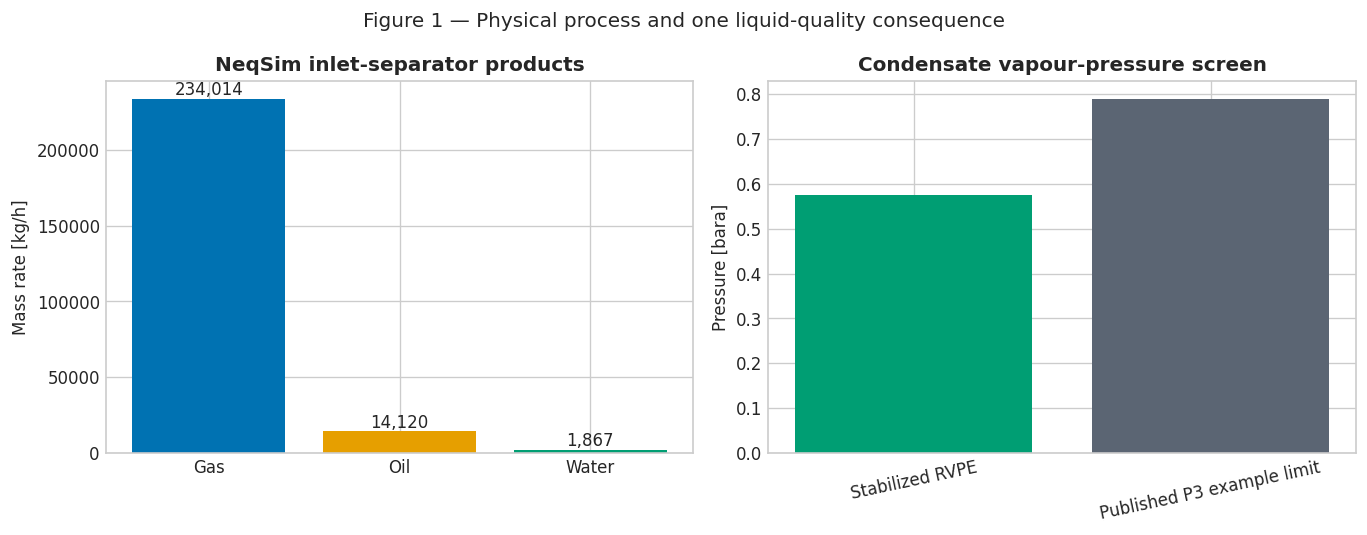

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
product_labels = ["Gas", "Oil", "Water"]
product_rates = [separator_gas_kg_h, separator_oil_kg_h, separator_water_kg_h]
axes[0].bar(product_labels, product_rates, color=[COLORS["blue"], COLORS["orange"], COLORS["green"]])
axes[0].set_ylabel("Mass rate [kg/h]")
axes[0].set_title("NeqSim inlet-separator products")
for index, value in enumerate(product_rates):
    axes[0].text(index, value, f"{value:,.0f}", ha="center", va="bottom")

axes[1].bar(
    ["Stabilized RVPE", "Published P3 example limit"],
    [stabilized_rvpe_bara, 0.79],
    color=[COLORS["green"], COLORS["grey"]],
)
axes[1].set_ylabel("Pressure [bara]")
axes[1].set_title("Condensate vapour-pressure screen")
axes[1].tick_params(axis="x", rotation=12)
figure.suptitle("Figure 1 — Physical process and one liquid-quality consequence")
figure.tight_layout()
plt.show()

### Interpret the process result correctly

The ASTM D6377-equivalent vapour-pressure result is below the published 0.79 bar P3 example in
this synthetic case. That does **not** certify the liquid. Free water, BS&W, oxygenates,
sampling, uncertainty, density, metering, storage weathering, and the exact contractual method
remain open. Similarly, 120 bara export pressure and a finite compressor duty do not prove that
the real compressor map, driver, cooler, control valve, or host power system has adequate margin.

A useful design-basis table always reports both the result and what remains outside the model.

## 8. ISO 6976 gas quality and blending margin

The dry-gas compositions below represent a host export stream and a conditioned tie-in export
stream after separating water and heavy liquids. ISO 6976 calculates gross calorific value (GCV),
net calorific value, Wobbe index, relative density, and density. The same reference and combustion
conditions must be used when comparing with a contractual range.

A dry-composition calculation cannot by itself prove water dew point or hydrocarbon dew point.
Those require a representative composition—including water/heavy ends—and a phase-envelope or
dedicated dehydration/dew-point model at the stated pressure.

In [11]:
HOST_DRY_GAS = {
    "methane": 0.905,
    "ethane": 0.055,
    "propane": 0.015,
    "i-butane": 0.003,
    "n-butane": 0.004,
    "nitrogen": 0.012,
    "CO2": 0.006,
}
TIE_DRY_GAS = {
    "methane": 0.850,
    "ethane": 0.075,
    "propane": 0.030,
    "i-butane": 0.006,
    "n-butane": 0.008,
    "nitrogen": 0.012,
    "CO2": 0.019,
}
STANDARD_TEMPERATURE_C = 15.0
COMBUSTION_REFERENCE_C = 25.0
STANDARD_PRESSURE_BARA = 1.01325


def build_srk_gas(composition, temperature_c, pressure_bara):
    gas = SystemSrkEos(temperature_c + 273.15, pressure_bara)
    for component_name, mole_fraction in composition.items():
        gas.addComponent(component_name, mole_fraction)
    gas.setMixingRule("classic")
    gas.setMultiPhaseCheck(False)
    gas.init(0)
    gas.init(1)
    gas.initPhysicalProperties()
    return gas


def iso6976_quality(composition):
    gas = build_srk_gas(
        composition, STANDARD_TEMPERATURE_C, STANDARD_PRESSURE_BARA
    )
    standard = StandardISO6976(
        gas,
        STANDARD_TEMPERATURE_C,
        COMBUSTION_REFERENCE_C,
        "volume",
    )
    standard.setReferenceState("real")
    standard.calculate()
    return {
        "GCV [MJ/Sm3]": standard.getValue("SuperiorCalorificValue") / 1000.0,
        "NCV [MJ/Sm3]": standard.getValue("InferiorCalorificValue") / 1000.0,
        "Wobbe [MJ/Sm3]": standard.getValue("SuperiorWobbeIndex") / 1000.0,
        "Relative density [-]": standard.getValue("RelativeDensity"),
        "Density [kg/Sm3]": gas.getDensity("kg/m3"),
    }


quality_table = pd.DataFrame(
    [iso6976_quality(HOST_DRY_GAS), iso6976_quality(TIE_DRY_GAS)],
    index=["Host dry gas", "Conditioned tie dry gas"],
)
display(quality_table.round(5))

,GCV [MJ/Sm3],NCV [MJ/Sm3],Wobbe [MJ/Sm3],Relative density [-],Density [kg/Sm3]
Host dry gas,40.07281,36.21202,51.00865,0.61718,0.75641
Conditioned tie dry gas,41.59900,37.65265,51.03283,0.66446,0.81434


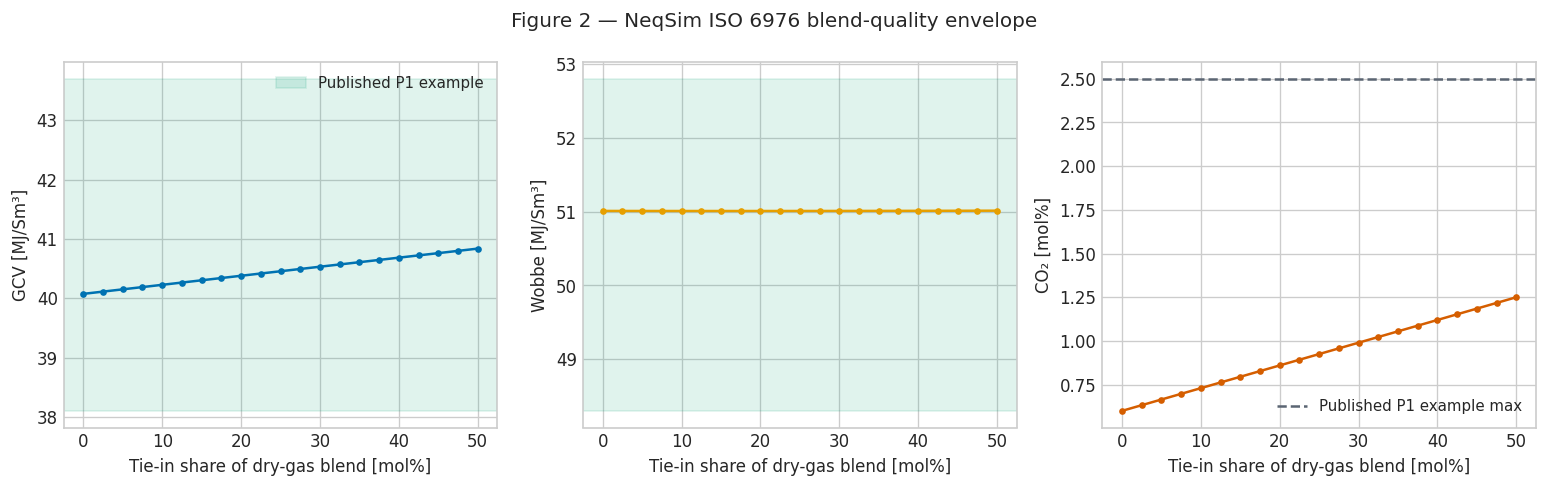

,Tie fraction [%],CO2 [mol%],GCV [MJ/Sm3],NCV [MJ/Sm3],Wobbe [MJ/Sm3],Relative density [-],Density [kg/Sm3]
0,0.0,0.6000,40.07281,36.21202,51.00865,0.61718,0.75641
5,12.5,0.7625,40.26346,36.39198,51.00783,0.62309,0.76365
10,25.0,0.9250,40.45415,36.57198,51.00817,0.62899,0.77089
15,37.5,1.0875,40.64487,36.75201,51.00964,0.63490,0.77813
20,50.0,1.2500,40.83563,36.93208,51.01220,0.64081,0.78537


In [12]:
def mole_blend(first, second, second_fraction):
    components = sorted(set(first) | set(second))
    blended = {
        component: (
            (1.0 - second_fraction) * first.get(component, 0.0)
            + second_fraction * second.get(component, 0.0)
        )
        for component in components
    }
    total = sum(blended.values())
    return {component: value / total for component, value in blended.items()}


blend_records = []
for tie_fraction in np.linspace(0.0, 0.50, 21):
    composition = mole_blend(HOST_DRY_GAS, TIE_DRY_GAS, tie_fraction)
    quality = iso6976_quality(composition)
    blend_records.append(
        {
            "Tie fraction [%]": 100.0 * tie_fraction,
            "CO2 [mol%]": 100.0 * composition["CO2"],
            **quality,
        }
    )
blend_table = pd.DataFrame(blend_records)

figure, axes = plt.subplots(1, 3, figsize=(13.0, 4.1), sharex=True)
axes[0].plot(blend_table["Tie fraction [%]"], blend_table["GCV [MJ/Sm3]"], color=COLORS["blue"], marker="o", ms=3)
axes[0].axhspan(38.1, 43.7, color=COLORS["green"], alpha=0.12, label="Published P1 example")
axes[0].set_ylabel("GCV [MJ/Sm³]")
axes[0].legend()
axes[1].plot(blend_table["Tie fraction [%]"], blend_table["Wobbe [MJ/Sm3]"], color=COLORS["orange"], marker="o", ms=3)
axes[1].axhspan(48.3, 52.8, color=COLORS["green"], alpha=0.12)
axes[1].set_ylabel("Wobbe [MJ/Sm³]")
axes[2].plot(blend_table["Tie fraction [%]"], blend_table["CO2 [mol%]"], color=COLORS["red"], marker="o", ms=3)
axes[2].axhline(2.50, color=COLORS["grey"], ls="--", label="Published P1 example max")
axes[2].set_ylabel("CO₂ [mol%]")
axes[2].legend()
for axis in axes:
    axis.set_xlabel("Tie-in share of dry-gas blend [mol%]")
figure.suptitle("Figure 2 — NeqSim ISO 6976 blend-quality envelope")
figure.tight_layout()
plt.show()
display(blend_table.iloc[[0, 5, 10, 15, 20]].round(5))

### Quality headroom is a capacity

For one linear constituent such as CO₂, a screening upper bound on tie-in rate is obtainable from
a simple mixing balance. For host rate $q_h$, host concentration $x_h$, tie concentration $x_t$,
and maximum mixed concentration $x_{max}$:

$$q_{t,quality} = q_h\,\frac{x_{max}-x_h}{x_t-x_{max}}$$

when $x_h < x_{max} < x_t$. If the tie gas is already below the limit, this constituent does not
impose that bound. The relation is useful for screening but not a substitute for the operator's
contractual blending model, analyser uncertainty, spatial mixing, linepack, transient nomination,
other contaminants, dew point, or quality-service availability.

## 9. 2026 Gassco tariff snapshot: K, I, O, booking vintage, and services

The official tariff view publishes monthly unit tariff components. This notebook freezes selected
August 2026 values relevant to a teaching route. In simplified form:

- **K** is the capital element and differs between “new” and “old” elements/booking situations;
- **I** is an operating-cost element; and
- **O** is an additional element published by month.

The regulation and the applicable booking/service determine the legal calculation. Here we add
the published unit elements for a transparent classroom invoice screen. Blank/not-shown elements
in the selected rows are represented as zero **only in this frozen teaching table**—never infer a
real quote from that convention.

Route topology matters. Area O, P, and D below illustrate Polarled/Aasta Hansteen, Nyhamna, and a
dry-gas exit combination; they are not freely interchangeable labels. Quality services such as
CO₂/H₂S handling and fractionation can use different mass or volume units.

In [13]:
tariff_aug_2026 = pd.DataFrame(
    [
        ("O — Polarled/Aasta Hansteen", "new", 0.1604750, 0.0, 0.0195283, "NOK/Sm³"),
        ("P — Nyhamna", "new", 0.2050513, 0.0, 0.1457701, "NOK/Sm³"),
        ("D — exit", "new", 0.0126597, 0.0293205, 0.0369729, "NOK/Sm³"),
        ("L — UHGP", "new", 0.0353045, 0.0, 0.0194857, "NOK/Sm³"),
        ("C — extraction (EXT)", "new", 0.0178306, 0.0123904, 0.0828804, "NOK/Sm³"),
        ("C — CO₂ service", "new", 188.1123235, 129.0659278, 609.7435505, "NOK/tonne"),
        ("C — fractionation (FSL)", "new", 53.4916560, 193.8418678, 625.3942445, "NOK/tonne"),
    ],
    columns=["Area / service", "K vintage", "K", "I", "O (Aug 2026)", "Unit"],
)
tariff_aug_2026["Teaching total"] = tariff_aug_2026[["K", "I", "O (Aug 2026)"]].sum(axis=1)
display(tariff_aug_2026.style.hide(axis="index").format({"K": "{:.7f}", "I": "{:.7f}", "O (Aug 2026)": "{:.7f}", "Teaching total": "{:.7f}"}))

k_vintage_example = pd.DataFrame(
    [
        ("D — exit", "new K", 0.0126597),
        ("D — exit", "old K", 0.0993162),
    ],
    columns=["Area", "Published K category", "K [NOK/Sm³]"],
)
display(k_vintage_example.style.hide(axis="index").format({"K [NOK/Sm³]": "{:.7f}"}))

Area / service,K vintage,K,I,O (Aug 2026),Unit,Teaching total
O — Polarled/Aasta Hansteen,new,0.1604750,0.0000000,0.0195283,NOK/Sm³,0.1800033
P — Nyhamna,new,0.2050513,0.0000000,0.1457701,NOK/Sm³,0.3508214
D — exit,new,0.0126597,0.0293205,0.0369729,NOK/Sm³,0.0789531
L — UHGP,new,0.0353045,0.0000000,0.0194857,NOK/Sm³,0.0547902
C — extraction (EXT),new,0.0178306,0.0123904,0.0828804,NOK/Sm³,0.1131014
C — CO₂ service,new,188.1123235,129.0659278,609.7435505,NOK/tonne,926.9218018
C — fractionation (FSL),new,53.4916560,193.8418678,625.3942445,NOK/tonne,872.7277683


Area,Published K category,K [NOK/Sm³]
D — exit,new K,0.0126597
D — exit,old K,0.0993162


Area / service,K,I,O (Aug 2026),Teaching total
O — Polarled/Aasta Hansteen,0.1604750,0.0000000,0.0195283,0.1800033
P — Nyhamna,0.2050513,0.0000000,0.1457701,0.3508214
D — exit,0.0126597,0.0293205,0.0369729,0.0789531


,August 2026 teaching invoice screen
Route teaching total [NOK/Sm3],0.6098
Booked capacity [MSm3/day],5.0000
Actual throughput [MSm3/day],3.8000
Booked-volume charge screen [MNOK],94.5156
Throughput-only counterfactual [MNOK],71.8318
Unused-capacity exposure [MNOK],22.6837


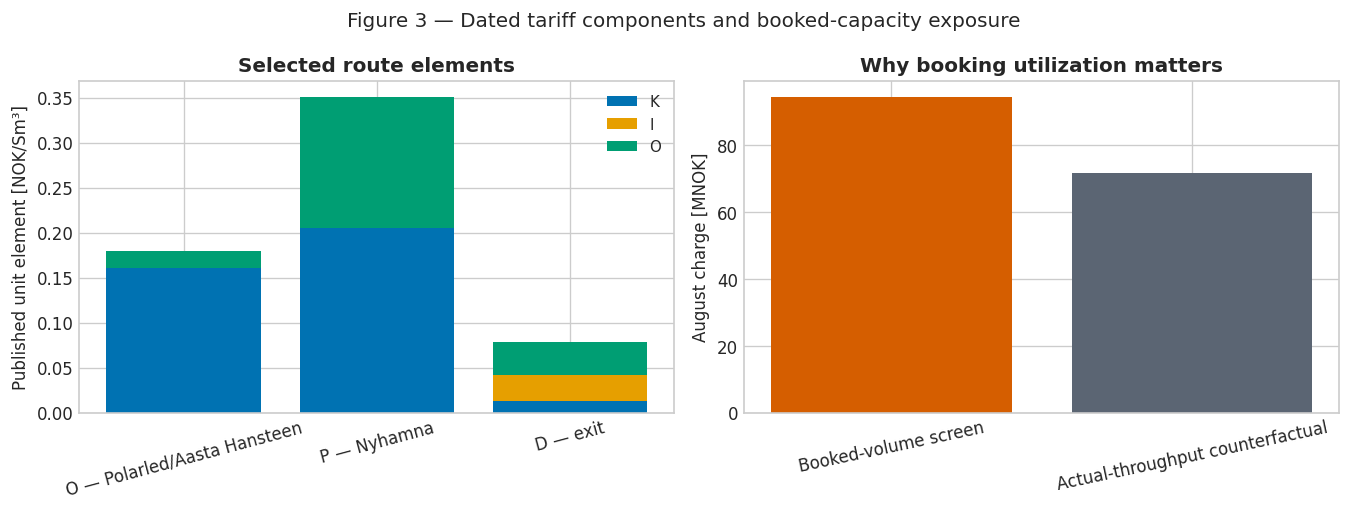

In [14]:
route_rows = [
    "O — Polarled/Aasta Hansteen",
    "P — Nyhamna",
    "D — exit",
]
route_table = tariff_aug_2026[
    tariff_aug_2026["Area / service"].isin(route_rows)
].copy()
route_unit_tariff_nok_sm3 = route_table["Teaching total"].sum()
booked_capacity_msm3_day = 5.0
august_days = 31
booked_august_sm3 = booked_capacity_msm3_day * 1.0e6 * august_days
actual_august_msm3_day = 3.8
actual_august_sm3 = actual_august_msm3_day * 1.0e6 * august_days
teaching_booked_charge_mnok = (
    route_unit_tariff_nok_sm3 * booked_august_sm3 / 1.0e6
)
throughput_counterfactual_mnok = (
    route_unit_tariff_nok_sm3 * actual_august_sm3 / 1.0e6
)
booking_summary = pd.Series(
    {
        "Route teaching total [NOK/Sm3]": route_unit_tariff_nok_sm3,
        "Booked capacity [MSm3/day]": booked_capacity_msm3_day,
        "Actual throughput [MSm3/day]": actual_august_msm3_day,
        "Booked-volume charge screen [MNOK]": teaching_booked_charge_mnok,
        "Throughput-only counterfactual [MNOK]": throughput_counterfactual_mnok,
        "Unused-capacity exposure [MNOK]": (
            teaching_booked_charge_mnok - throughput_counterfactual_mnok
        ),
    },
    name="August 2026 teaching invoice screen",
)
display(route_table[["Area / service", "K", "I", "O (Aug 2026)", "Teaching total"]].style.hide(axis="index").format({"K": "{:.7f}", "I": "{:.7f}", "O (Aug 2026)": "{:.7f}", "Teaching total": "{:.7f}"}))
display(booking_summary.to_frame().round(4))

figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].bar(route_table["Area / service"], route_table["K"], label="K", color=COLORS["blue"])
axes[0].bar(route_table["Area / service"], route_table["I"], bottom=route_table["K"], label="I", color=COLORS["orange"])
axes[0].bar(route_table["Area / service"], route_table["O (Aug 2026)"], bottom=route_table["K"] + route_table["I"], label="O", color=COLORS["green"])
axes[0].set_ylabel("Published unit element [NOK/Sm³]")
axes[0].set_title("Selected route elements")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()
axes[1].bar(["Booked-volume screen", "Actual-throughput counterfactual"], [teaching_booked_charge_mnok, throughput_counterfactual_mnok], color=[COLORS["red"], COLORS["grey"]])
axes[1].set_ylabel("August charge [MNOK]")
axes[1].set_title("Why booking utilization matters")
axes[1].tick_params(axis="x", rotation=12)
figure.suptitle("Figure 3 — Dated tariff components and booked-capacity exposure")
figure.tight_layout()
plt.show()

### Tariffs, processing fees, products, and taxes are different ledgers

Keep at least four ledgers:

- **transport capacity:** reservation/booking and route tariff elements;
- **processing and quality services:** extraction, CO₂/H₂S handling, fractionation, host service,
  fuel, flare, losses, shrinkage, recovered-products allocation, and incremental equipment;
- **sales and settlement:** dry-gas energy, condensate/NGL quantity, quality adjustments,
  imbalance, and true-up; and
- **tax:** ordinary income tax, special petroleum tax, depreciation, qualifying investment,
  uplift/transition items where relevant, and tax timing.

A transport tariff is normally a deductible project cost in an economic model; it is not itself a
tax. A processing “yield loss” may instead appear through shrinkage/recovery and product allocation,
not as one NOK/Sm³ line. Reconcile physical molecules, energy, allocated ownership, and cash.

## 10. Host capacity, priority, holdback, and quality reliance

**Host holdback** here means host potential that cannot be processed because capacity has been
allocated to the tie-in. **Tie-in curtailment** means tie-in potential not accepted. They are not
synonyms. A host-priority agreement can create tie curtailment with zero host holdback; a firm
tie reservation can do the opposite. Pro-rata allocation shares scarcity.

Relevant capacities are subsystem- and condition-specific: inlet separators, compression power
and map, dehydration, dew-point control, CO₂/H₂S treatment, water handling, produced-water
discharge, flare, metering, export pipeline, onshore plant, and planned/unplanned outages. The
governing capacity is the smallest simultaneous margin after derating.

The SODIR standard third-party clauses are useful public drafting context: they distinguish user,
owner/host, reserved capacity, tie-in work, and incremental equipment; they also address the user
paying for work/equipment, fuel/flare allocation, and possible compensation when tie-in work causes
shutdown beyond schedule. The signed agreement remains controlling.

In [15]:
years = np.arange(2028, 2043)
host_potential_msm3_day = np.linspace(18.0, 8.0, len(years))
tie_potential_msm3_day = np.array(
    [3.5, 4.7, 5.2, 5.2, 5.0, 4.8, 4.5, 4.2, 3.9, 3.6, 3.3, 3.0, 2.7, 2.4, 2.1]
)
physical_limits = {
    "inlet gas capacity": 21.0,
    "export capacity": 20.0,
    "compression-equivalent capacity": 19.5,
}
effective_shared_capacity = min(physical_limits.values())


def co2_quality_capacity(host_rate, host_co2, tie_co2, maximum_co2):
    if tie_co2 <= maximum_co2:
        return np.full_like(host_rate, np.inf, dtype=float)
    numerator = np.maximum(maximum_co2 - host_co2, 0.0)
    return host_rate * numerator / (tie_co2 - maximum_co2)


def allocate_shared_capacity(policy, quality_case="conditioned"):
    if quality_case == "conditioned":
        tie_co2 = 0.019
        host_co2 = 0.006
    elif quality_case == "blending reliance":
        tie_co2 = 0.038
        host_co2 = 0.022
    else:
        raise ValueError("Unknown quality case")
    quality_limit = co2_quality_capacity(
        host_potential_msm3_day, host_co2, tie_co2, 0.025
    )
    tie_quality_limited = np.minimum(tie_potential_msm3_day, quality_limit)

    if policy == "host priority":
        host_accepted = np.minimum(host_potential_msm3_day, effective_shared_capacity)
        tie_accepted = np.minimum(
            tie_quality_limited,
            np.maximum(effective_shared_capacity - host_accepted, 0.0),
        )
    elif policy == "firm tie first":
        tie_accepted = np.minimum(tie_quality_limited, effective_shared_capacity)
        host_accepted = np.minimum(
            host_potential_msm3_day,
            np.maximum(effective_shared_capacity - tie_accepted, 0.0),
        )
    elif policy == "pro rata":
        total = host_potential_msm3_day + tie_quality_limited
        scale = np.minimum(1.0, effective_shared_capacity / total)
        host_accepted = host_potential_msm3_day * scale
        tie_accepted = tie_quality_limited * scale
    else:
        raise ValueError("Unknown policy")
    return pd.DataFrame(
        {
            "Year": years,
            "Host potential": host_potential_msm3_day,
            "Tie potential": tie_potential_msm3_day,
            "Host accepted": host_accepted,
            "Tie accepted": tie_accepted,
            "Host holdback": host_potential_msm3_day - host_accepted,
            "Tie curtailment": tie_potential_msm3_day - tie_accepted,
            "CO2 quality capacity": quality_limit,
            "Shared capacity": effective_shared_capacity,
            "Policy": policy,
            "Quality case": quality_case,
        }
    )


allocation_cases = pd.concat(
    [
        allocate_shared_capacity(policy, quality_case)
        for policy in ["host priority", "pro rata", "firm tie first"]
        for quality_case in ["conditioned", "blending reliance"]
    ],
    ignore_index=True,
)
display(pd.DataFrame({"Subsystem": physical_limits.keys(), "Capacity [MSm3/day]": physical_limits.values()}).style.hide(axis="index"))
display(allocation_cases[(allocation_cases["Year"] == 2029)].round(3))

Subsystem,Capacity [MSm3/day]
inlet gas capacity,21.000000
export capacity,20.000000
compression-equivalent capacity,19.500000


,Year,Host potential,Tie potential,Host accepted,Tie accepted,Host holdback,Tie curtailment,CO2 quality capacity,Shared capacity,Policy,Quality case
1,2029,17.286,4.7,17.286,2.214,0.000,2.486,inf,19.5,host priority,conditioned
16,2029,17.286,4.7,17.286,2.214,0.000,2.486,3.989,19.5,host priority,blending reliance
31,2029,17.286,4.7,15.331,4.169,1.954,0.531,inf,19.5,pro rata,conditioned
46,2029,17.286,4.7,15.844,3.656,1.442,1.044,3.989,19.5,pro rata,blending reliance
61,2029,17.286,4.7,14.800,4.700,2.486,0.000,inf,19.5,firm tie first,conditioned
76,2029,17.286,4.7,15.511,3.989,1.775,0.711,3.989,19.5,firm tie first,blending reliance


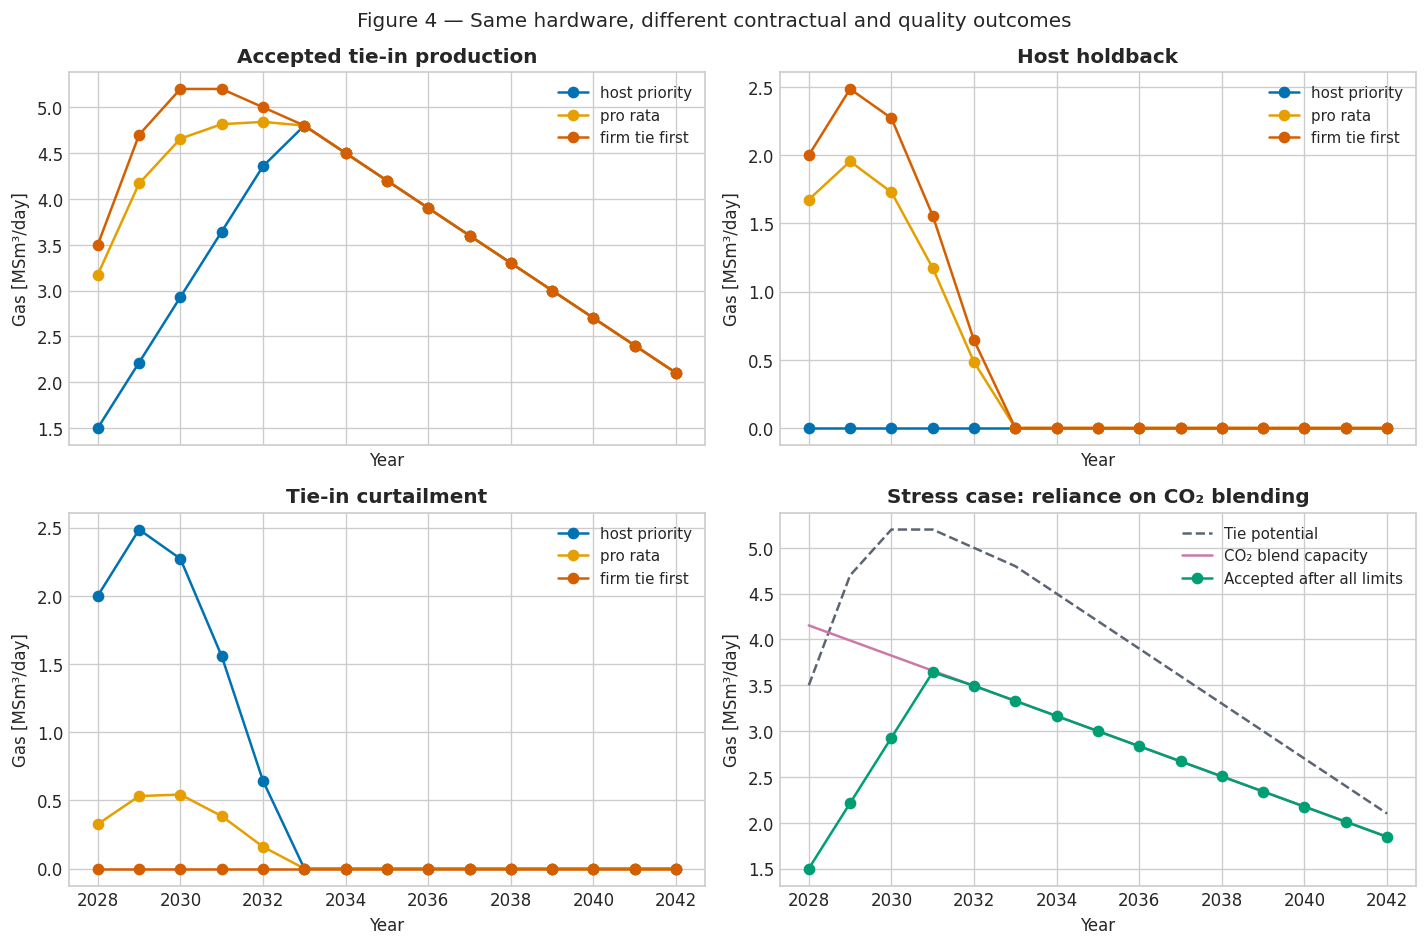

In [16]:
conditioned_cases = allocation_cases[
    allocation_cases["Quality case"] == "conditioned"
]
quality_stress = allocation_cases[
    (allocation_cases["Quality case"] == "blending reliance")
    & (allocation_cases["Policy"] == "host priority")
]
figure, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), sharex=True)
for policy, color in zip(
    ["host priority", "pro rata", "firm tie first"],
    [COLORS["blue"], COLORS["orange"], COLORS["red"]],
):
    case = conditioned_cases[conditioned_cases["Policy"] == policy]
    axes[0, 0].plot(case["Year"], case["Tie accepted"], marker="o", label=policy, color=color)
    axes[0, 1].plot(case["Year"], case["Host holdback"], marker="o", label=policy, color=color)
    axes[1, 0].plot(case["Year"], case["Tie curtailment"], marker="o", label=policy, color=color)
axes[1, 1].plot(quality_stress["Year"], quality_stress["Tie potential"], label="Tie potential", color=COLORS["grey"], ls="--")
axes[1, 1].plot(quality_stress["Year"], quality_stress["CO2 quality capacity"], label="CO₂ blend capacity", color=COLORS["purple"])
axes[1, 1].plot(quality_stress["Year"], quality_stress["Tie accepted"], label="Accepted after all limits", color=COLORS["green"], marker="o")
titles = ["Accepted tie-in production", "Host holdback", "Tie-in curtailment", "Stress case: reliance on CO₂ blending"]
for axis, title in zip(axes.flat, titles):
    axis.set_title(title)
    axis.set_ylabel("Gas [MSm³/day]")
    axis.set_xlabel("Year")
    axis.legend()
figure.suptitle("Figure 4 — Same hardware, different contractual and quality outcomes")
figure.tight_layout()
plt.show()

### How to evaluate holdback in a real tie-in

1. Obtain the host’s **unconstrained** production and facility demand by subsystem and time step.
2. Agree deratings, maintenance, ramp-up, turndown, trips, restart restrictions, and uncertainty.
3. Run the combined host + tie fluids through the operator-accepted process/flow-assurance model.
4. Apply product-quality, chemical, emission, flare, produced-water, metering, and export constraints.
5. Apply the signed priority/allocation policy and identify both host holdback and tie curtailment.
6. Value deferred volumes—not only lost volumes—using field decline, reservoir interaction, tax,
   prices, and later capacity. Add shutdown compensation and incremental-equipment terms.
7. Test who controls the operating set point and who pays when the shared optimum changes.

A useful commercial metric is the **marginal value of one unit of headroom** at each subsystem.
It supports comparison of debottleneck capex, extra quality service, host compensation, alternative
routes, storage/linepack flexibility, and a changed production schedule.

## 11. Accepted production to pre-tax and post-tax value

The economic case below uses the **pro-rata, conditioned-gas** allocation—not the unconstrained
tie profile. Gas sales use the calculated NeqSim tie-gas GCV. Transport uses the booked capacity
and the dated teaching route total; host processing and liquid price are synthetic assumptions.

Public Norwegian tax guidance describes a cash-flow-based petroleum tax since 2022, with 22%
ordinary income tax and a 71.8% technical special-tax rate designed to maintain an overall 78%
rate. Qualifying offshore investment is immediately deductible in the special-tax basis, while
ordinary-tax depreciation is generally straight-line over six years (special cases exist).

This notebook uses a deliberately simplified approximation:

$$Tax_t = 0.78\,EBITDA_t - 0.22\,Depreciation_t$$

and applies a 71.8% immediate special-tax value to qualifying capex. It assumes a tax-paying group
can realize negative special-tax value without delay. It excludes finance, loss timing, norm-price
detail, decommissioning, abandonment security, transfer pricing, uplift/transition complexity,
indirect taxes, and asset-specific eligibility. Obtain a project tax model and legal review.

In [17]:
selected_allocation = allocation_cases[
    (allocation_cases["Policy"] == "pro rata")
    & (allocation_cases["Quality case"] == "conditioned")
].reset_index(drop=True)
tie_quality = iso6976_quality(TIE_DRY_GAS)
GCV_MJ_SM3 = tie_quality["GCV [MJ/Sm3]"]
DAYS_PER_YEAR = 350.0
NOK_PER_EUR = 12.0
GAS_PRICE_EUR_MWH = 35.0
CONDENSATE_PRICE_NOK_BBL = 700.0
CONDENSATE_YIELD_SM3_PER_MSM3_GAS = 150.0
BBL_PER_SM3 = 6.28981
HOST_PROCESSING_NOK_SM3 = 0.10
FIXED_OPEX_BNOK_YEAR = 0.55
VARIABLE_OPEX_NOK_SM3 = 0.06
BOOKED_CAPACITY_MSM3_DAY = 5.0
CAPEX_BNOK = {2026: 3.0, 2027: 5.0}
DISCOUNT_RATE = 0.08

economics = selected_allocation[["Year", "Tie potential", "Tie accepted", "Tie curtailment"]].copy()
economics["Gas energy [million MWh]"] = (
    economics["Tie accepted"] * 1.0e6 * DAYS_PER_YEAR * GCV_MJ_SM3 / 3600.0 / 1.0e6
)
economics["Gas revenue [BNOK]"] = (
    economics["Gas energy [million MWh]"] * GAS_PRICE_EUR_MWH * NOK_PER_EUR / 1000.0
)
economics["Condensate [thousand bbl]"] = (
    economics["Tie accepted"] * CONDENSATE_YIELD_SM3_PER_MSM3_GAS * DAYS_PER_YEAR * BBL_PER_SM3 / 1000.0
)
economics["Condensate revenue [BNOK]"] = economics["Condensate [thousand bbl]"] * CONDENSATE_PRICE_NOK_BBL / 1.0e6
economics["Gassled booked tariff [BNOK]"] = (
    BOOKED_CAPACITY_MSM3_DAY * 1.0e6 * DAYS_PER_YEAR * route_unit_tariff_nok_sm3 / 1.0e9
)
economics["Host processing [BNOK]"] = (
    economics["Tie accepted"] * 1.0e6 * DAYS_PER_YEAR * HOST_PROCESSING_NOK_SM3 / 1.0e9
)
economics["Variable OPEX [BNOK]"] = (
    economics["Tie accepted"] * 1.0e6 * DAYS_PER_YEAR * VARIABLE_OPEX_NOK_SM3 / 1.0e9
)
economics["EBITDA [BNOK]"] = (
    economics["Gas revenue [BNOK]"]
    + economics["Condensate revenue [BNOK]"]
    - economics["Gassled booked tariff [BNOK]"]
    - economics["Host processing [BNOK]"]
    - economics["Variable OPEX [BNOK]"]
    - FIXED_OPEX_BNOK_YEAR
)
display(economics.round(3))

,Year,Tie potential,Tie accepted,Tie curtailment,Gas energy [million MWh],Gas revenue [BNOK],Condensate [thousand bbl],Condensate revenue [BNOK],Gassled booked tariff [BNOK],Host processing [BNOK],Variable OPEX [BNOK],EBITDA [BNOK]
0,2028,3.5,3.174,0.326,12.838,5.392,1048.241,0.734,1.067,0.111,0.067,4.331
1,2029,4.7,4.169,0.531,16.859,7.081,1376.540,0.964,1.067,0.146,0.088,6.194
2,2030,5.2,4.657,0.543,18.836,7.911,1537.970,1.077,1.067,0.163,0.098,7.110
3,2031,5.2,4.815,0.385,19.475,8.180,1590.140,1.113,1.067,0.169,0.101,7.406
4,2032,5.0,4.840,0.160,19.576,8.222,1598.381,1.119,1.067,0.169,0.102,7.453
5,2033,4.8,4.800,0.000,19.413,8.153,1585.032,1.110,1.067,0.168,0.101,7.377
6,2034,4.5,4.500,0.000,18.200,7.644,1485.968,1.040,1.067,0.158,0.094,6.815
7,2035,4.2,4.200,0.000,16.986,7.134,1386.903,0.971,1.067,0.147,0.088,6.253
8,2036,3.9,3.900,0.000,15.773,6.625,1287.839,0.901,1.067,0.136,0.082,5.691
9,2037,3.6,3.600,0.000,14.560,6.115,1188.774,0.832,1.067,0.126,0.076,5.128


In [18]:
project_years = np.arange(2026, 2043)
cash_flow = pd.DataFrame({"Year": project_years})
cash_flow["Capex [BNOK]"] = cash_flow["Year"].map(CAPEX_BNOK).fillna(0.0)
cash_flow = cash_flow.merge(
    economics[["Year", "EBITDA [BNOK]"]], how="left", on="Year"
).fillna({"EBITDA [BNOK]": 0.0})

depreciation = np.zeros(len(cash_flow))
for capex_year, amount in CAPEX_BNOK.items():
    start = np.where(project_years == capex_year)[0][0]
    depreciation[start : min(start + 6, len(depreciation))] += amount / 6.0
cash_flow["Ordinary depreciation [BNOK]"] = depreciation
cash_flow["Pre-tax cash flow [BNOK]"] = cash_flow["EBITDA [BNOK]"] - cash_flow["Capex [BNOK]"]
cash_flow["Simplified tax payment [BNOK]"] = (
    0.78 * cash_flow["EBITDA [BNOK]"]
    - 0.22 * cash_flow["Ordinary depreciation [BNOK]"]
    - 0.718 * cash_flow["Capex [BNOK]"]
)
cash_flow["Simplified post-tax cash flow [BNOK]"] = (
    cash_flow["Pre-tax cash flow [BNOK]"]
    - cash_flow["Simplified tax payment [BNOK]"]
)
cash_flow["Discount factor"] = (1.0 + DISCOUNT_RATE) ** (
    cash_flow["Year"] - cash_flow["Year"].min()
)
pre_tax_npv_bnok = (
    cash_flow["Pre-tax cash flow [BNOK]"] / cash_flow["Discount factor"]
).sum()
post_tax_npv_bnok = (
    cash_flow["Simplified post-tax cash flow [BNOK]"]
    / cash_flow["Discount factor"]
).sum()
npv_summary = pd.Series(
    {
        "Pre-tax NPV8 [BNOK]": pre_tax_npv_bnok,
        "Simplified post-tax NPV8 [BNOK]": post_tax_npv_bnok,
        "Route unit tariff snapshot [NOK/Sm3]": route_unit_tariff_nok_sm3,
        "Tie gas GCV [MJ/Sm3]": GCV_MJ_SM3,
        "Lifecycle tie curtailment [billion Sm3]": (
            economics["Tie curtailment"].sum() * DAYS_PER_YEAR / 1000.0
        ),
    },
    name="Economic screen",
)
display(cash_flow.round(3))
display(npv_summary.to_frame().round(3))

,Year,Capex [BNOK],EBITDA [BNOK],Ordinary depreciation [BNOK],Pre-tax cash flow [BNOK],Simplified tax payment [BNOK],Simplified post-tax cash flow [BNOK],Discount factor
0,2026,3.0,0.000,0.500,-3.000,-2.264,-0.736,1.000
1,2027,5.0,0.000,1.333,-5.000,-3.883,-1.117,1.080
2,2028,0.0,4.331,1.333,4.331,3.085,1.246,1.166
3,2029,0.0,6.194,1.333,6.194,4.538,1.656,1.260
4,2030,0.0,7.110,1.333,7.110,5.252,1.858,1.360
5,2031,0.0,7.406,1.333,7.406,5.483,1.923,1.469
6,2032,0.0,7.453,0.833,7.453,5.630,1.823,1.587
7,2033,0.0,7.377,0.000,7.377,5.754,1.623,1.714
8,2034,0.0,6.815,0.000,6.815,5.316,1.499,1.851
9,2035,0.0,6.253,0.000,6.253,4.877,1.376,1.999


,Economic screen
Pre-tax NPV8 [BNOK],37.955
Simplified post-tax NPV8 [BNOK],9.274
Route unit tariff snapshot [NOK/Sm3],0.610
Tie gas GCV [MJ/Sm3],41.599
Lifecycle tie curtailment [billion Sm3],0.680


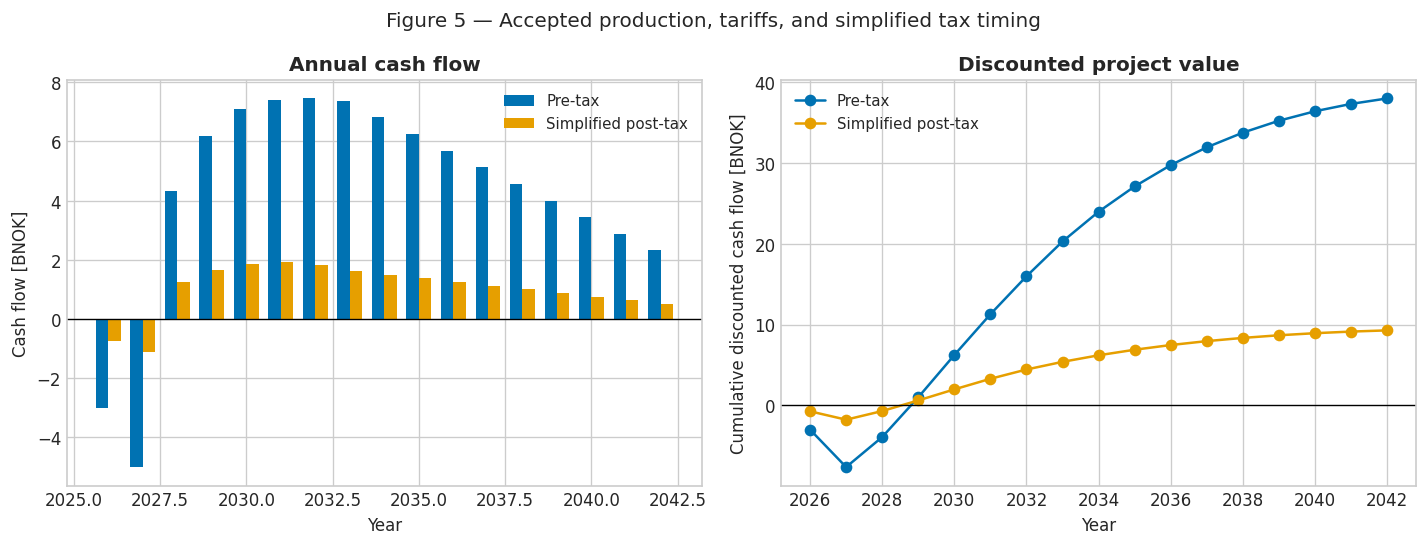

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].bar(cash_flow["Year"] - 0.18, cash_flow["Pre-tax cash flow [BNOK]"], width=0.36, label="Pre-tax", color=COLORS["blue"])
axes[0].bar(cash_flow["Year"] + 0.18, cash_flow["Simplified post-tax cash flow [BNOK]"], width=0.36, label="Simplified post-tax", color=COLORS["orange"])
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_ylabel("Cash flow [BNOK]")
axes[0].set_title("Annual cash flow")
axes[0].legend()
cumulative_pre = np.cumsum(cash_flow["Pre-tax cash flow [BNOK]"] / cash_flow["Discount factor"])
cumulative_post = np.cumsum(cash_flow["Simplified post-tax cash flow [BNOK]"] / cash_flow["Discount factor"])
axes[1].plot(cash_flow["Year"], cumulative_pre, label="Pre-tax", color=COLORS["blue"], marker="o")
axes[1].plot(cash_flow["Year"], cumulative_post, label="Simplified post-tax", color=COLORS["orange"], marker="o")
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_ylabel("Cumulative discounted cash flow [BNOK]")
axes[1].set_title("Discounted project value")
axes[1].legend()
for axis in axes:
    axis.set_xlabel("Year")
figure.suptitle("Figure 5 — Accepted production, tariffs, and simplified tax timing")
figure.tight_layout()
plt.show()

### Tax and tariff interpretation checkpoints

- Tax rates apply to defined tax bases, not directly to revenue; deductions and timing matter.
- A large early special-tax deduction is not “free capex”: the remaining after-tax investment,
  ordinary depreciation, operational tax, and project risk still matter.
- Norm-price rules can affect taxable crude-oil income; do not substitute a forecast sales price
  without checking the applicable basis.
- Capacity charges can persist during outages or curtailment depending on rights and rules.
- Host processing, fuel, shrinkage, recovery, allocation, and quality services can dominate the
  difference between field revenue and market netback even if each line seems small per Sm³.
- Compare concepts on the same tax, price, FX, inflation, discount, booking, and abandonment basis.

## 12. Uncertainty: tariff, price, availability, capex, and start date

A deterministic case can conceal the interaction between unused booked capacity and a delayed or
constrained ramp-up. The seeded Monte Carlo below varies five teaching assumptions and reuses the
transparent post-tax structure. Correlations, operator outages, reservoir uncertainty, FX, price
shape, tax-loss timing, and discrete rebooking decisions should be added in a project model.

In [20]:
rng = np.random.default_rng(20260821)
n_samples = 1200
sample_records = []
base_acceptance = economics["Tie accepted"].to_numpy()

def post_tax_npv_sample(gas_price, availability, capex_total, tariff_factor, delay):
    accepted = np.clip(base_acceptance * availability, 0.0, None)
    if delay:
        accepted = np.r_[np.zeros(delay), accepted[:-delay]]
    gas_energy = accepted * 1.0e6 * DAYS_PER_YEAR * GCV_MJ_SM3 / 3600.0
    gas_revenue = gas_energy * gas_price * NOK_PER_EUR / 1.0e9
    condensate_revenue = (
        accepted
        * CONDENSATE_YIELD_SM3_PER_MSM3_GAS
        * DAYS_PER_YEAR
        * BBL_PER_SM3
        * CONDENSATE_PRICE_NOK_BBL
        / 1.0e9
    )
    transport = (
        BOOKED_CAPACITY_MSM3_DAY
        * 1.0e6
        * DAYS_PER_YEAR
        * route_unit_tariff_nok_sm3
        * tariff_factor
        / 1.0e9
    )
    host_and_variable = accepted * 1.0e6 * DAYS_PER_YEAR * (
        HOST_PROCESSING_NOK_SM3 + VARIABLE_OPEX_NOK_SM3
    ) / 1.0e9
    ebitda = (
        gas_revenue
        + condensate_revenue
        - transport
        - host_and_variable
        - FIXED_OPEX_BNOK_YEAR
    )
    sample_capex = {2026: 0.375 * capex_total, 2027: 0.625 * capex_total}
    sample_cf = np.zeros(len(project_years))
    sample_dep = np.zeros(len(project_years))
    sample_cf[2:] = ebitda
    for capex_year, amount in sample_capex.items():
        index = int(capex_year - project_years[0])
        sample_cf[index] -= amount
        sample_cf[index] += 0.718 * amount
        sample_dep[index : min(index + 6, len(sample_dep))] += amount / 6.0
    sample_cf -= 0.78 * np.r_[np.zeros(2), ebitda]
    sample_cf += 0.22 * sample_dep
    return np.sum(sample_cf / (1.0 + DISCOUNT_RATE) ** np.arange(len(sample_cf)))


for _ in range(n_samples):
    gas_price = max(rng.normal(35.0, 7.0), 10.0)
    availability = np.clip(rng.normal(0.92, 0.07), 0.65, 1.0)
    capex_total = max(rng.normal(8.0, 1.4), 4.0)
    tariff_factor = np.clip(rng.normal(1.0, 0.15), 0.65, 1.45)
    delay = int(rng.choice([0, 1, 2], p=[0.65, 0.25, 0.10]))
    sample_records.append(
        {
            "Gas price [EUR/MWh]": gas_price,
            "Availability factor": availability,
            "Capex [BNOK]": capex_total,
            "Tariff factor": tariff_factor,
            "Start delay [years]": delay,
            "Simplified post-tax NPV8 [BNOK]": post_tax_npv_sample(
                gas_price, availability, capex_total, tariff_factor, delay
            ),
        }
    )
uncertainty = pd.DataFrame(sample_records)
npv_quantiles = uncertainty["Simplified post-tax NPV8 [BNOK]"].quantile([0.10, 0.50, 0.90])
rank_correlation = uncertainty.corr(method="spearman")["Simplified post-tax NPV8 [BNOK]"].drop("Simplified post-tax NPV8 [BNOK]").sort_values()
display(npv_quantiles.rename("NPV [BNOK]").to_frame().round(3))
display(rank_correlation.rename("Spearman rank correlation").to_frame().round(3))

,NPV [BNOK]
0.1,4.668
0.5,7.608
0.9,10.825


,Spearman rank correlation
Start delay [years],-0.268
Tariff factor,-0.114
Capex [BNOK],-0.074
Availability factor,0.332
Gas price [EUR/MWh],0.873


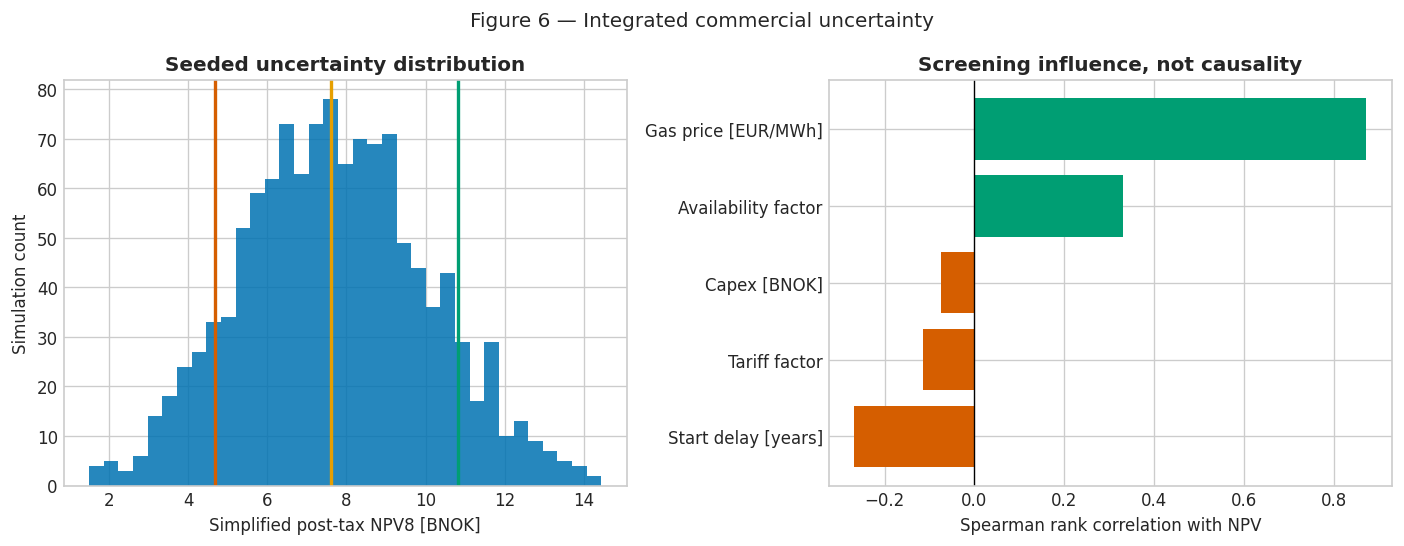

In [21]:
figure, axes = plt.subplots(1, 2, figsize=(11.8, 4.6))
axes[0].hist(uncertainty["Simplified post-tax NPV8 [BNOK]"], bins=35, color=COLORS["blue"], alpha=0.85)
for quantile, color in zip(npv_quantiles, [COLORS["red"], COLORS["orange"], COLORS["green"]]):
    axes[0].axvline(quantile, color=color, lw=2)
axes[0].set_xlabel("Simplified post-tax NPV8 [BNOK]")
axes[0].set_ylabel("Simulation count")
axes[0].set_title("Seeded uncertainty distribution")
axes[1].barh(rank_correlation.index, rank_correlation.values, color=[COLORS["red"] if value < 0 else COLORS["green"] for value in rank_correlation.values])
axes[1].axvline(0.0, color="black", lw=0.8)
axes[1].set_xlabel("Spearman rank correlation with NPV")
axes[1].set_title("Screening influence, not causality")
figure.suptitle("Figure 6 — Integrated commercial uncertainty")
figure.tight_layout()
plt.show()

## 13. A decision-gate workflow

**Gate A — frame the route.** Name reservoir, tie-in point, host train, gas/liquid export points,
Gassco areas/services, delivery point, ownership, and target dates. Notify Gassco early when a
transport/processing need may arise and align the GMDC forecast with the development schedule.

**Gate B — prove envelopes.** Establish probabilistic production, composition, contaminants,
pressure/temperature, liquid yield, water, chemicals, turndown, ramp-up, and outages. Maintain
source and sample provenance.

**Gate C — close host integration.** Use operator-accepted combined-fluid models, subsystem
capacities, control philosophy, brownfield work, shutdown windows, incremental equipment,
reliability, emissions, metering, and SIMOPS. Quantify host holdback and tie curtailment under the
proposed priority terms.

**Gate D — close products and infrastructure.** Confirm every specification, method, reference
condition, quality service, booking quantity/vintage, nomination, shrinkage/recovery factor,
allocation, tariff component, and invoice rule. Stress off-spec and low-blend-gas conditions.

**Gate E — close commercial and tax value.** Link accepted production to sales energy/liquids,
tariffs, processing, compensation, capex, opex, emissions cost, tax, abandonment, financing, and
uncertainty. Preserve decision traceability.

**Gate F — operating readiness.** Commission analysers/meters, validate allocation, agree alarms,
notices, reduction order, restart, sample retention, laboratory fallback, and dispute/true-up
processes before first production.

In [22]:
gate_register = pd.DataFrame(
    [
        ("Route framed", "named areas, services, custody points, dates", "Commercial/Gassco", "open until operator-confirmed"),
        ("Fluid envelope", "PVT/composition provenance and uncertainty", "Subsurface/NeqSim", "screened here; replace synthetic fluid"),
        ("Host capacity", "combined model, deratings, outages, priority", "Host integration", "screened here; operator model required"),
        ("Gas quality", "all entry/exit limits and measurement uncertainty", "Gas quality", "partial: GCV/Wobbe/CO2 only"),
        ("Liquid quality", "RVP/TVP, water, BS&W, oxygenates", "Oil quality", "partial: RVPE only"),
        ("Tariff/booking", "route, K vintage, I/O month, quantity", "Gassco/commercial", "dated teaching snapshot only"),
        ("Allocation", "fuel/flare/loss/shrinkage/recovery/true-up", "Metering/commercial", "not yet field-specific"),
        ("Tax/economics", "reviewed tax model and uncertainty", "Economics/tax", "simplified teaching model only"),
        ("Operability", "alarm, off-spec, trip, restart, notices", "Operations", "procedure not developed"),
    ],
    columns=["Gate evidence", "Minimum acceptance evidence", "Owner", "Notebook status"],
)
display(gate_register.style.hide(axis="index"))

Gate evidence,Minimum acceptance evidence,Owner,Notebook status
Route framed,"named areas, services, custody points, dates",Commercial/Gassco,open until operator-confirmed
Fluid envelope,PVT/composition provenance and uncertainty,Subsurface/NeqSim,screened here; replace synthetic fluid
Host capacity,"combined model, deratings, outages, priority",Host integration,screened here; operator model required
Gas quality,all entry/exit limits and measurement uncertainty,Gas quality,partial: GCV/Wobbe/CO2 only
Liquid quality,"RVP/TVP, water, BS&W, oxygenates",Oil quality,partial: RVPE only
Tariff/booking,"route, K vintage, I/O month, quantity",Gassco/commercial,dated teaching snapshot only
Allocation,fuel/flare/loss/shrinkage/recovery/true-up,Metering/commercial,not yet field-specific
Tax/economics,reviewed tax model and uncertainty,Economics/tax,simplified teaching model only
Operability,"alarm, off-spec, trip, restart, notices",Operations,procedure not developed


## 14. Validation and machine-checkable claims

Assertions below prevent a visually plausible notebook from passing with broken balances,
incorrect composition totals, unbounded allocation, invalid quality values, inconsistent tariff
arithmetic, or unordered uncertainty quantiles. They validate this educational case—not the real
field decision.

In [23]:
engineering_checks = {
    "wellstream composition sums to one": math.isclose(sum(wellstream_composition.values()), 1.0, abs_tol=1.0e-12),
    "host dry-gas composition sums to one": math.isclose(sum(HOST_DRY_GAS.values()), 1.0, abs_tol=1.0e-12),
    "tie dry-gas composition sums to one": math.isclose(sum(TIE_DRY_GAS.values()), 1.0, abs_tol=1.0e-12),
    "NeqSim inlet mass balance closes": inlet_mass_residual < 1.0e-8,
    "NeqSim stabilizer mass balance closes": stabilization_mass_residual < 1.0e-8,
    "export compressor has positive power": compressor_power_mw > 0.0,
    "export pressure target is reached": math.isclose(float(export_cooler.getOutletStream().getPressure("bara")), 120.0, rel_tol=1.0e-7),
    "ASTM D6377 result is finite": np.isfinite(stabilized_rvpe_bara),
    "synthetic RVPE passes published P3 example": stabilized_rvpe_bara <= 0.79,
    "ISO 6976 results are finite": bool(np.isfinite(blend_table.select_dtypes(include=[np.number])).all().all()),
    "tariff route arithmetic closes": math.isclose(route_unit_tariff_nok_sm3, 0.6097778, abs_tol=1.0e-7),
    "allocations remain non-negative": bool((allocation_cases[["Host accepted", "Tie accepted", "Host holdback", "Tie curtailment"]] >= -1.0e-12).all().all()),
    "allocations respect shared capacity": bool(((allocation_cases["Host accepted"] + allocation_cases["Tie accepted"]) <= effective_shared_capacity + 1.0e-12).all()),
    "accepted tie never exceeds potential": bool((allocation_cases["Tie accepted"] <= allocation_cases["Tie potential"] + 1.0e-12).all()),
    "cash-flow values are finite": bool(np.isfinite(cash_flow.select_dtypes(include=[np.number])).all().all()),
    "uncertainty NPV quantiles are ordered": bool(np.all(np.diff(npv_quantiles.to_numpy()) > 0.0)),
    "gate register exposes open evidence": bool(gate_register["Notebook status"].str.contains("required|only|partial|not yet|not developed").any()),
}
failed_checks = [name for name, passed in engineering_checks.items() if not passed]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"
check_table = pd.DataFrame(
    {
        "Engineering check": list(engineering_checks),
        "Result": ["PASS" if passed else "FAIL" for passed in engineering_checks.values()],
    }
)
display(check_table.style.hide(axis="index"))
print(f"All {len(engineering_checks)} named engineering checks passed.")

All 17 named engineering checks passed.


Engineering check,Result
wellstream composition sums to one,PASS
host dry-gas composition sums to one,PASS
tie dry-gas composition sums to one,PASS
NeqSim inlet mass balance closes,PASS
NeqSim stabilizer mass balance closes,PASS
export compressor has positive power,PASS
export pressure target is reached,PASS
ASTM D6377 result is finite,PASS
synthetic RVPE passes published P3 example,PASS
ISO 6976 results are finite,PASS


## 15. How to replace the synthetic case with a real opportunity

Replace inputs in this order, keeping a versioned case manifest:

1. **Fluid and production:** validated EOS/PVT, compositional envelope, contaminants, water,
   chemicals, solids, rate/pressure/temperature percentiles, ramp-up and turndown.
2. **Facilities:** well/SURF hydraulics, arrival states, host equipment curves, control set points,
   duty/standby philosophy, availabilities, brownfield scope, outages, flare/emissions, and
   produced-water capacity.
3. **Products:** signed inlet/export/sales specifications with methods and uncertainty; laboratory
   data; online analyser and sample-system performance; stabilization/dehydration/dew-point and
   quality-service models.
4. **Infrastructure:** named route, GMDC cases, booking round, start date, booking vintage,
   quantities, shipper-specific shrinkage/recovery factors, nominations, quality notices, and all
   current K/I/O or service elements.
5. **Commercial:** capacity priority, reduction order, host holdback/deferment compensation,
   incremental equipment, operating fee, fuel/flare/loss, allocation, imbalance, off-spec
   liability, shutdown, insurance, force majeure, decommissioning, and dispute rules.
6. **Economics and tax:** real prices/FX/inflation, capex/opex classes, tariff escalation and
   rebooking, norm-price assumptions where relevant, exact tax bases and timing, abandonment,
   financing, and correlated uncertainty.

Re-run the whole chain whenever one interface changes. A richer reservoir profile can lower value
if it increases early host holdback, exceeds booked capacity, triggers quality treatment, or pushes
liquids outside stabilization capacity.

## 16. Model boundary and conclusions

### What this notebook demonstrates

- Current-source NeqSim bootstrap with recorded commit/JAR provenance.
- A real SRK gas-condensate process, three-phase split, export compression, stabilization, ASTM
  D6377 vapour pressure, and ISO 6976 gas quality.
- Boundary-specific specification thinking and the difference between entry quality, processing
  service, dry-gas exit quality, and condensate quality.
- A dated 2026 K/I/O tariff snapshot, booking-vintage awareness, route addition, quality-service
  units, and booked-capacity utilization exposure.
- Explicit host priority, firm tie, and pro-rata outcomes; separate host holdback and tie
  curtailment; and quality headroom as a capacity.
- Accepted-production economics with transport, processing, products, simplified petroleum tax,
  and uncertainty.

### What it does not decide

It is not a calibrated field model, host capacity statement, Gassco booking, certified gas/condensate
quality report, tariff quote, signed processing agreement, allocation procedure, metering design,
legal interpretation, tax return, reserves statement, or investment basis. It omits detailed
reservoir physics, multiphase transient flow assurance, dehydration/dew-point/acid-gas units,
equipment maps and reliability, dynamic operations, sulfur/mercury/oxygenate chemistry, emissions
compliance, and field-specific tax/accounting detail.

### Final decision rule

Do not approve the tie-in because its unconstrained production is valuable. Approve a concept only
when **accepted production** closes every named boundary with adequate margin, owned mitigation,
operable rules, bookable capacity, reconciled quantities, and a risked after-tax value that remains
robust under holdback, quality, outage, tariff, price, and schedule uncertainty.

## References

- [Gassco — Tariffs and areas](https://gassco.eu/en/shippers/tariffs-and-areas/) and
  [2026 unit-tariff view](https://umm.gassco.no/UnitPrices/pdf).
- [Gassco Shipper Manual, 1 January 2026](https://gassco.eu/wp-content/uploads/2026/01/Shipper-Manual-01.01.2026.pdf).
- [Gassco GMDC Guideline](https://gassco.eu/wp-content/uploads/2025/06/GMDC-Guideline.pdf).
- [Nyhamna Terms and Conditions, 1 October 2023](https://gassco.eu/wp-content/uploads/2023/10/Nyhamna-Terms-and-Conditions-01.10.2023-w-attachments.pdf).
- [Lovdata — tariff regulation for access to facilities](https://lovdata.no/dokument/SF/forskrift/2002-12-20-1724/%C2%A74).
- [SODIR — Standard clauses for third-party use of facilities](https://www.sodir.no/4aee90/globalassets/1-sodir/regelverk/rapportering/bruk-av-innretninger/standard-avtaleklausuler.pdf).
- [Norwegian Tax Administration — petroleum tax regulations](https://www.skatteetaten.no/en/business-and-organisation/reporting-and-industries/industries-special-regulations/oil-and-gas-exploration-and-petroleum-tax/the-petroleum-tax-office-and-the-petroleum-tax-system/petroleum-tax-regulations/).
- [NeqSim source and documentation](https://github.com/equinor/neqsim).

**Snapshot date:** 21 August 2026. Regulations, tariffs, manuals, facility terms, and tax guidance
can change; re-verify official sources for every real decision.